# ExoScout v0.4 — Feature Importance and Error Analysis

This notebook investigates which features contribute most to the Random Forest predictions and which types of observations the model misclassifies.

All analysis is performed using only the development set. The final holdout remains untouched because it will be used only once, after the final pipeline has been selected. Inspecting it or making decisions based on it would compromise its role as an independent final evaluation.

A high feature importance indicates that the model relies strongly on the information contained in that feature. However, it does not prove that the feature is essential, nor that it has a causal relationship with the target.

## Evaluation Strategy

Error analysis is based on out-of-fold predictions from the development set.

For each cross-validation fold, the model is trained on four folds and predicts observations in the remaining unseen fold. The process is repeated until every development observation has received a prediction from a model that was not trained on it.

The folds remain group-aware using TIC ID (`tid`), preventing TOIs belonging to the same host star from appearing in both the training and validation portions of a fold.

The final holdout is not used during this analysis.

In [1]:
import sys
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.load_data import load_data

df = load_data()

In [2]:
df.shape


(8113, 10)

## Data Preparation

The NASA TOI catalog is filtered to observations labeled as Confirmed Planets (`CP`), Known Planets (`KP`), or False Positives (`FP`).

`CP` and `KP` are mapped to the positive class (`1`), while `FP` is mapped to the negative class (`0`).

The model uses seven transit and stellar features. TIC ID (`tid`) is excluded from the predictive features and retained only as a grouping variable.

In [3]:
filtered_df = df[df["tfopwg_disp"].isin(["CP", "KP", "FP"])].copy()

mapping = {
    "CP": 1,
    "KP": 1,
    "FP": 0
}

filtered_df["target"] = filtered_df["tfopwg_disp"].map(mapping)

In [4]:
features = [
    "pl_orbper",
    "pl_trandurh",
    "pl_trandep",
    "st_tmag",
    "st_teff",
    "st_logg",
    "st_rad"
]

X = filtered_df[features]
Y = filtered_df["target"]
groups = filtered_df["tid"]

## Group-Aware Development and Holdout Split

The same group-aware split introduced in v0.3 is reconstructed to preserve the existing evaluation protocol.

One fold, approximately 20% of the labeled data, is reserved as the final holdout. The remaining observations form the development set used throughout v0.4.

TIC ID (`tid`) is used as the grouping variable, ensuring that TOIs belonging to the same host star cannot appear in both partitions.

The final holdout remains untouched during feature analysis, error analysis, and model selection.

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

holdout_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [6]:
dev_idx, holdout_idx = next(
    holdout_splitter.split(X, Y, groups=groups)
)

In [7]:
dev_idx[:10]

array([ 0,  1,  2,  3,  6,  7,  8,  9, 10, 11])

In [8]:
X_dev = X.iloc[dev_idx]

X_dev.shape

(2077, 7)

In [9]:
X_holdout = X.iloc[holdout_idx]

X_holdout.shape

(519, 7)

In [10]:
Y_dev = Y.iloc[dev_idx]
Y_holdout = Y.iloc[holdout_idx]

In [11]:
Y_dev.shape, Y_holdout.shape

((2077,), (519,))

In [12]:
groups_dev = groups.iloc[dev_idx]
groups_holdout = groups.iloc[holdout_idx]

In [13]:
len(set(groups_dev) & set(groups_holdout))

0

The development and holdout sets share zero TIC IDs, confirming complete host-star separation.

## Group-Aware Cross-Validation

All v0.4 analyses are performed using 5-fold stratified group cross-validation on the development set.

Each validation observation is evaluated by a model that was not trained on it, while TIC ID (`tid`) prevents TOIs from the same host star appearing in both portions of a fold.

In [14]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Random Forest Pipeline

The v0.3 Random Forest pipeline is reused without changing its preprocessing or model parameters.

Missing numerical values are replaced with medians learned only from the corresponding training data. Missingness indicators are added so that the model can also use the presence of missing values as predictive information.

Keeping preprocessing inside the pipeline prevents information from the validation folds from influencing imputation.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42
        )
    )
])

## Out-of-Fold Predictions

Out-of-fold predictions are generated for every observation in the development set.

Each observation receives a predicted class and probability from a Random Forest pipeline trained without that observation or any other TOI belonging to the same host star.

In [16]:
import numpy as np

oof_predictions = np.full(
    len(X_dev),
    fill_value=-1,
    dtype=int
)

oof_probabilities = np.full(
    len(X_dev),
    fill_value=np.nan,
    dtype=float
)

oof_fold_ids = np.full(
    len(X_dev),
    fill_value=-1,
    dtype=int
)

### Fold Structure Check

Before generating predictions, the cross-validation folds are inspected to verify their sizes and confirm that no TIC ID is shared between the training and validation portions.

In [17]:
for fold_id, (fold_train_idx, fold_validation_idx) in enumerate(
    cv.split(
        X_dev,
        Y_dev,
        groups=groups_dev
    ),
    start=1
):
    train_groups = groups_dev.iloc[fold_train_idx]
    validation_groups = groups_dev.iloc[fold_validation_idx]

    shared_groups = set(train_groups) & set(validation_groups)

    print(
        f"Fold {fold_id}: "
        f"train={len(fold_train_idx)}, "
        f"validation={len(fold_validation_idx)}, "
        f"shared hosts={len(shared_groups)}"
    )

Fold 1: train=1662, validation=415, shared hosts=0
Fold 2: train=1662, validation=415, shared hosts=0
Fold 3: train=1662, validation=415, shared hosts=0
Fold 4: train=1661, validation=416, shared hosts=0
Fold 5: train=1661, validation=416, shared hosts=0


The five validation folds contain 415–416 observations each. No TIC ID is shared between the training and validation portions of any fold, confirming that the group-aware constraint is respected.


### Prediction Generation

For each fold, a fresh copy of the Random Forest pipeline is fitted on the training portion and used to predict the corresponding unseen validation portion.

Predicted classes, planet probabilities, and fold identifiers are stored in their original development-set positions.

In [18]:
from sklearn.base import clone

for fold_id, (fold_train_idx, fold_validation_idx) in enumerate(
    cv.split(
        X_dev,
        Y_dev,
        groups=groups_dev
    ),
    start=1
):
    X_train_fold = X_dev.iloc[fold_train_idx]
    Y_train_fold = Y_dev.iloc[fold_train_idx]

    X_validation_fold = X_dev.iloc[fold_validation_idx]

    fold_pipeline = clone(random_forest_pipeline)

    fold_pipeline.fit(
        X_train_fold,
        Y_train_fold
    )

    oof_predictions[fold_validation_idx] = (
        fold_pipeline.predict(X_validation_fold)
    )

    oof_probabilities[fold_validation_idx] = (
        fold_pipeline.predict_proba(X_validation_fold)[:, 1]
    )

    oof_fold_ids[fold_validation_idx] = fold_id

### Prediction Completeness Check

The stored outputs are checked to ensure that every development observation received a prediction, probability, and fold identifier.

In [19]:
missing_predictions = (oof_predictions == -1).sum()
missing_probabilities = np.isnan(oof_probabilities).sum()
missing_fold_ids = (oof_fold_ids == -1).sum()

print("Missing predictions:", missing_predictions)
print("Missing probabilities:", missing_probabilities)
print("Missing fold IDs:", missing_fold_ids)

Missing predictions: 0
Missing probabilities: 0
Missing fold IDs: 0


## Out-of-Fold Performance Check

The combined out-of-fold predictions are evaluated to verify that the manual validation loop remains consistent with the grouped cross-validation results reported in v0.3.

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

oof_accuracy = accuracy_score(
    Y_dev,
    oof_predictions
)

oof_precision = precision_score(
    Y_dev,
    oof_predictions
)

oof_recall = recall_score(
    Y_dev,
    oof_predictions
)

oof_f1 = f1_score(
    Y_dev,
    oof_predictions
)

print(f"Accuracy:  {oof_accuracy:.3f}")
print(f"Precision: {oof_precision:.3f}")
print(f"Recall:    {oof_recall:.3f}")
print(f"F1-score:  {oof_f1:.3f}")

Accuracy:  0.822
Precision: 0.802
Recall:    0.871
F1-score:  0.835


The pooled out-of-fold predictions achieved:

- Accuracy: 82.2%
- Planet precision: 80.2%
- Planet recall: 87.1%
- Planet F1-score: 83.5%

These results are consistent with the grouped cross-validation results reported in v0.3, confirming that the manual out-of-fold procedure reproduces the existing evaluation protocol.

Recall remains higher than precision: the model identifies most planet-class observations, while producing a larger proportion of false-positive planet predictions.

## Impurity-Based Feature Importance

A Random Forest pipeline is fitted on the complete development set to inspect its internal impurity-based feature importances.

These importances measure how much each input reduces classification impurity across the forest's decision trees. They describe how the fitted model uses its inputs, but do not establish causality or guarantee usefulness on unseen data.

Because impurity-based importance is derived from training statistics and can favor features with many possible split values, it will later be compared with out-of-fold permutation importance.

In [21]:
rf_dev_pipeline = clone(random_forest_pipeline)

rf_dev_pipeline.fit(
    X_dev,
    Y_dev
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pl_orbper','pl_trandurh','pl_trandep',...,'st_teff','st_logg','st_rad']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",True
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder fo

In [22]:
rf_dev_pipeline.named_steps["model"].feature_importances_

array([0.15503979, 0.13888935, 0.15556928, 0.10221987, 0.13117632,
       0.12288409, 0.14604294, 0.00207918, 0.00136276, 0.03342226,
       0.01131417])

In [23]:
fitted_imputer = rf_dev_pipeline.named_steps["imputer"]
fitted_random_forest = rf_dev_pipeline.named_steps["model"]

transformed_feature_names = (
    fitted_imputer.get_feature_names_out(features)
)

transformed_feature_names

array(['pl_orbper', 'pl_trandurh', 'pl_trandep', 'st_tmag', 'st_teff',
       'st_logg', 'st_rad', 'missingindicator_pl_orbper',
       'missingindicator_st_teff', 'missingindicator_st_logg',
       'missingindicator_st_rad'], dtype=object)

### Impurity-Based Importance Ranking

The importance values are matched with the transformed feature names and sorted from highest to lowest.

The values are normalized and sum to one. They represent each feature's relative contribution to impurity reduction within the fitted forest.


In [24]:
impurity_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "impurity_importance": (
        fitted_random_forest.feature_importances_
    )
})

impurity_importance_df = (
    impurity_importance_df
    .sort_values(
        "impurity_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

impurity_importance_df

,feature,impurity_importance
0,pl_trandep,0.155569
1,pl_orbper,0.155040
2,st_rad,0.146043
3,pl_trandurh,0.138889
4,st_teff,0.131176
5,st_logg,0.122884
6,st_tmag,0.102220
7,missingindicator_st_logg,0.033422
8,missingindicator_st_rad,0.011314
9,missingindicator_pl_orbper,0.002079


### Initial Impurity-Importance Observation

The seven original astronomical features have relatively distributed impurity importances, with no single feature dominating the fitted forest.

Transit depth (`pl_trandep`) and orbital period (`pl_orbper`) rank highest, closely followed by stellar radius (`st_rad`) and transit duration (`pl_trandurh`).

Missingness indicators account for a smaller share of the total importance. Among them, missingness in stellar surface gravity (`st_logg`) has the largest contribution.

These results describe the internal behavior of the fitted forest and are treated as preliminary until compared with out-of-fold permutation importance.

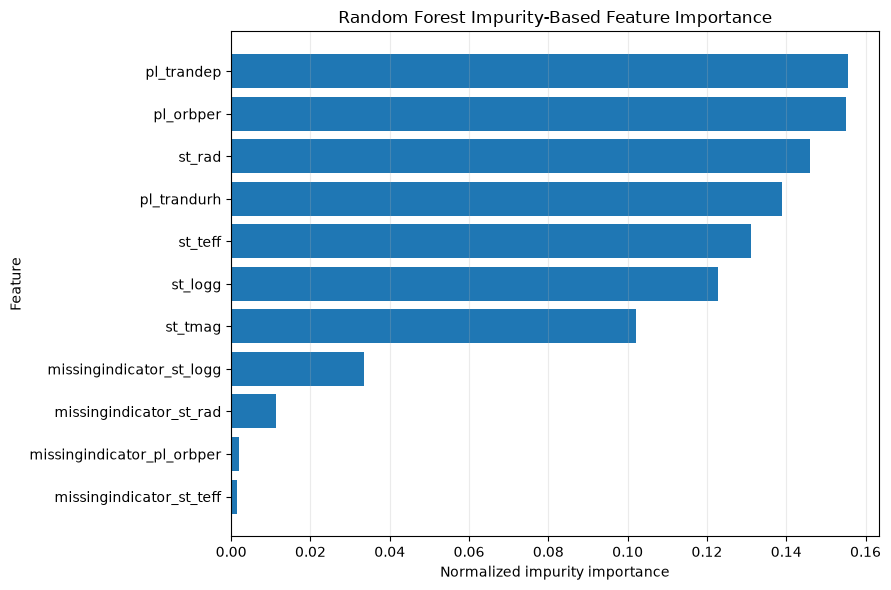

In [25]:
import matplotlib.pyplot as plt

impurity_plot_df = (
    impurity_importance_df
    .sort_values("impurity_importance")
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    impurity_plot_df["feature"],
    impurity_plot_df["impurity_importance"]
)

ax.set_title("Random Forest Impurity-Based Feature Importance")
ax.set_xlabel("Normalized impurity importance")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()

## Out-of-Fold Permutation Importance

Permutation importance is computed separately on each group-aware validation fold.

For every fold, a fresh Random Forest pipeline is trained on the corresponding training portion. Each original feature is then shuffled repeatedly in the unseen validation data, and the resulting decrease in accuracy is measured.

This evaluates whether the information used by the model remains useful on observations and host stars not seen during training.

In [26]:
from sklearn.inspection import permutation_importance



In [27]:
fold_permutation_results = []
for fold_id, (fold_train_idx, fold_validation_idx) in enumerate(
    cv.split(
        X_dev,
        Y_dev,
        groups=groups_dev
    ),
    start=1
):
    X_train_fold = X_dev.iloc[fold_train_idx]
    Y_train_fold = Y_dev.iloc[fold_train_idx]

    X_validation_fold = X_dev.iloc[fold_validation_idx]
    Y_validation_fold = Y_dev.iloc[fold_validation_idx]

    fold_pipeline = clone(random_forest_pipeline)

    fold_pipeline.fit(
        X_train_fold,
        Y_train_fold
    )

    permutation_result = permutation_importance(
        fold_pipeline,
        X_validation_fold,
        Y_validation_fold,
        scoring="accuracy",
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    fold_result_df = pd.DataFrame({
        "fold": fold_id,
        "feature": features,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std
    })

    fold_permutation_results.append(fold_result_df)

    print(f"Completed fold {fold_id}")

Completed fold 1
Completed fold 2
Completed fold 3
Completed fold 4
Completed fold 5


### Fold-Level Permutation Results

The permutation results from the five validation folds are combined into a single table. Each feature has one row per fold, containing its mean accuracy decrease and the variability across repeated shuffles.

In [28]:
fold_permutation_df = pd.concat(
    fold_permutation_results,
    ignore_index=True
)

fold_permutation_df.shape

(35, 4)

### Aggregated Permutation Importance

For each original feature, the mean accuracy decrease is averaged across the five validation folds.

Variability is reported in two forms:

- `std_across_folds`: how much the mean importance changes across different validation folds;
- `mean_shuffle_std`: the average variability caused by the 20 random permutations within each fold.

In [29]:
permutation_importance_df = (
    fold_permutation_df
    .groupby(
        "feature",
        as_index=False
    )
    .agg(
        mean_accuracy_decrease=(
            "importance_mean",
            "mean"
        ),
        std_across_folds=(
            "importance_mean",
            "std"
        ),
        mean_shuffle_std=(
            "importance_std",
            "mean"
        )
    )
    .sort_values(
        "mean_accuracy_decrease",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_importance_df

,feature,mean_accuracy_decrease,std_across_folds,mean_shuffle_std
0,pl_orbper,0.084828,0.008498,0.012136
1,pl_trandurh,0.079589,0.010384,0.012103
2,pl_trandep,0.078205,0.015818,0.013184
3,st_rad,0.065124,0.011276,0.014748
4,st_logg,0.060711,0.007463,0.013024
5,st_teff,0.057227,0.009525,0.012368
6,st_tmag,0.016581,0.007626,0.009064


### Permutation-Importance Results

Across the five group-aware validation folds, shuffling orbital period (`pl_orbper`) produced the largest mean accuracy decrease at approximately 8.5 percentage points.

Transit duration (`pl_trandurh`) and transit depth (`pl_trandep`) followed closely, reducing accuracy by approximately 8.0 and 7.8 percentage points respectively.

Stellar radius, surface gravity, and effective temperature also produced substantial decreases of approximately 5.7–6.5 percentage points.

TESS magnitude (`st_tmag`) had the smallest effect, reducing accuracy by approximately 1.7 percentage points.

All seven features have positive mean permutation importance, but the model relies considerably less on `st_tmag` than suggested by its impurity-based importance.

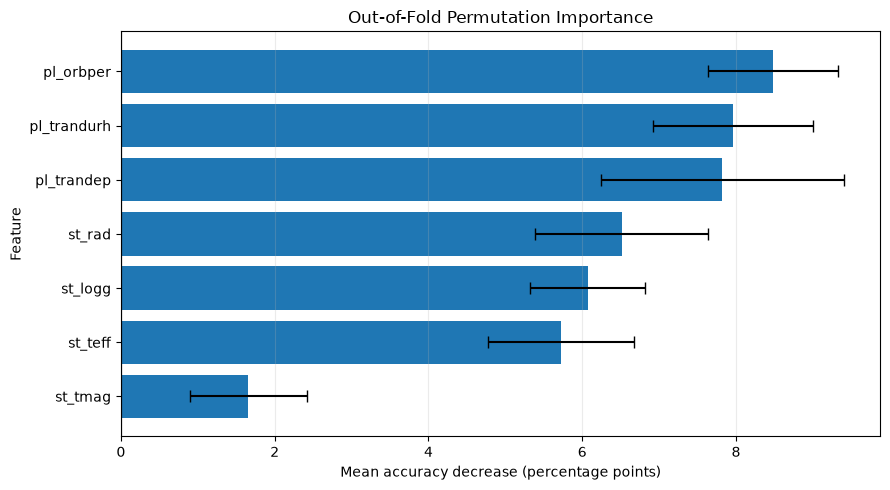

In [30]:
permutation_plot_df = (
    permutation_importance_df
    .assign(
        mean_decrease_pp=lambda df: (
            df["mean_accuracy_decrease"] * 100
        ),
        fold_std_pp=lambda df: (
            df["std_across_folds"] * 100
        )
    )
    .sort_values("mean_decrease_pp")
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    permutation_plot_df["feature"],
    permutation_plot_df["mean_decrease_pp"],
    xerr=permutation_plot_df["fold_std_pp"],
    capsize=4
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_title("Out-of-Fold Permutation Importance")
ax.set_xlabel("Mean accuracy decrease (percentage points)")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()

## Comparison of Importance Methods

To compare both methods at the same level, each impurity-based missingness-indicator importance is combined with the importance of its corresponding original feature.

This produces seven impurity-based values matching the seven original features evaluated by permutation importance.

The magnitudes remain fundamentally different, so the comparison focuses primarily on ranking rather than absolute values.

In [31]:
impurity_by_feature_df = (
    impurity_importance_df
    .assign(
        base_feature=lambda df: (
            df["feature"]
            .str.replace(
                "missingindicator_",
                "",
                regex=False
            )
        )
    )
    .groupby(
        "base_feature",
        as_index=False
    )
    .agg(
        impurity_importance=(
            "impurity_importance",
            "sum"
        )
    )
    .rename(
        columns={
            "base_feature": "feature"
        }
    )
)

importance_comparison_df = (
    impurity_by_feature_df
    .merge(
        permutation_importance_df,
        on="feature"
    )
)

importance_comparison_df["impurity_rank"] = (
    importance_comparison_df["impurity_importance"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

importance_comparison_df["permutation_rank"] = (
    importance_comparison_df["mean_accuracy_decrease"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

importance_comparison_df = (
    importance_comparison_df[
        [
            "feature",
            "impurity_importance",
            "impurity_rank",
            "mean_accuracy_decrease",
            "std_across_folds",
            "permutation_rank"
        ]
    ]
    .sort_values("permutation_rank")
    .reset_index(drop=True)
)

importance_comparison_df

,feature,impurity_importance,impurity_rank,mean_accuracy_decrease,std_across_folds,permutation_rank
0,pl_orbper,0.157119,2,0.084828,0.008498,1
1,pl_trandurh,0.138889,5,0.079589,0.010384,2
2,pl_trandep,0.155569,4,0.078205,0.015818,3
3,st_rad,0.157357,1,0.065124,0.011276,4
4,st_logg,0.156306,3,0.060711,0.007463,5
5,st_teff,0.132539,6,0.057227,0.009525,6
6,st_tmag,0.102220,7,0.016581,0.007626,7


### Importance Comparison

The two methods show partial agreement.

Orbital period ranks near the top with both methods, while effective temperature and TESS magnitude retain the same sixth and seventh positions.

However, transit duration rises from fifth under impurity importance to second under permutation importance. Stellar radius and surface gravity fall from first and third to fourth and fifth respectively.

This suggests that the forest uses stellar radius and surface gravity extensively when constructing its trees, but disrupting transit-related features has a larger effect on predictions for unseen validation observations.

TESS magnitude consistently ranks last and causes only a small accuracy decrease when permuted, providing stronger evidence that it currently contributes the least predictive information.

These rankings describe model reliance rather than physical causality. Correlated features may also substitute for one another and reduce their individual permutation importance.

## Out-of-Fold Error Analysis

The stored out-of-fold predictions are combined with the original development observations to identify true positives, true negatives, false positives, and false negatives.

Because every prediction was generated by a model that did not train on that observation or its host star, these errors provide a realistic view of the model's current failure modes without using the final holdout.

In [32]:
error_analysis_df = filtered_df.loc[
    X_dev.index,
    [
        "toi",
        "tid",
        "tfopwg_disp",
        *features
    ]
].copy()

error_analysis_df["true_label"] = Y_dev.to_numpy()
error_analysis_df["predicted_label"] = oof_predictions
error_analysis_df["planet_probability"] = oof_probabilities
error_analysis_df["fold"] = oof_fold_ids

conditions = [
    (
        (error_analysis_df["true_label"] == 1)
        & (error_analysis_df["predicted_label"] == 1)
    ),
    (
        (error_analysis_df["true_label"] == 0)
        & (error_analysis_df["predicted_label"] == 0)
    ),
    (
        (error_analysis_df["true_label"] == 0)
        & (error_analysis_df["predicted_label"] == 1)
    ),
    (
        (error_analysis_df["true_label"] == 1)
        & (error_analysis_df["predicted_label"] == 0)
    )
]

prediction_types = [
    "true_positive",
    "true_negative",
    "false_positive",
    "false_negative"
]

error_analysis_df["prediction_type"] = np.select(
    conditions,
    prediction_types,
    default="unknown"
)

error_analysis_df[
    [
        "toi",
        "tfopwg_disp",
        "true_label",
        "predicted_label",
        "planet_probability",
        "fold",
        "prediction_type"
    ]
].head()

,toi,tfopwg_disp,true_label,predicted_label,planet_probability,fold,prediction_type
1,1064.01,CP,1,1,0.94,3,true_positive
2,1064.02,CP,1,1,0.93,3,true_positive
3,1065.01,KP,1,1,0.52,1,true_positive
4,1066.01,KP,1,1,0.88,3,true_positive
7,1069.01,KP,1,1,0.80,5,true_positive


### Prediction Outcome Counts

The out-of-fold predictions are grouped into the four possible classification outcomes to quantify the model's correct decisions and errors.

In [ ]:
assert not (
    error_analysis_df["prediction_type"] == "unknown"
).any()

prediction_type_counts = (
    error_analysis_df["prediction_type"]
    .value_counts()
    .reindex(
        [
            "true_positive",
            "true_negative",
            "false_positive",
            "false_negative"
        ],
        fill_value=0
    )
)

prediction_type_counts

prediction_type
true_positive     935
true_negative     773
false_positive    231
false_negative    138
Name: count, dtype: int64

### Confusion Matrix

The confusion matrix summarizes the out-of-fold predictions by comparing the true class with the predicted class.

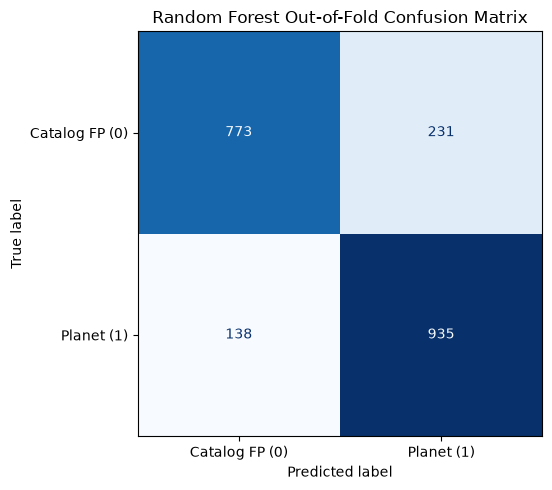

In [34]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

confusion = confusion_matrix(
    Y_dev,
    oof_predictions,
    labels=[0, 1]
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        "Catalog FP (0)",
        "Planet (1)"
    ]
)

fig, ax = plt.subplots(figsize=(6, 5))

display.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

ax.set_title("Random Forest Out-of-Fold Confusion Matrix")

fig.tight_layout()
plt.show()

### Prediction Confidence

Prediction confidence is defined as the probability assigned to the class selected by the model.

This allows uncertain errors near the decision threshold to be distinguished from errors made with high confidence.

In [35]:
error_analysis_df["prediction_confidence"] = np.where(
    error_analysis_df["predicted_label"] == 1,
    error_analysis_df["planet_probability"],
    1 - error_analysis_df["planet_probability"]
)

confidence_summary = (
    error_analysis_df
    .groupby("prediction_type")
    .agg(
        count=(
            "prediction_confidence",
            "size"
        ),
        mean_confidence=(
            "prediction_confidence",
            "mean"
        ),
        median_confidence=(
            "prediction_confidence",
            "median"
        )
    )
    .reindex(
        [
            "true_positive",
            "true_negative",
            "false_positive",
            "false_negative"
        ]
    )
)

confidence_summary

,count,mean_confidence,median_confidence
prediction_type,,,
true_positive,935,0.785412,0.80
true_negative,773,0.829198,0.86
false_positive,231,0.678398,0.66
false_negative,138,0.648043,0.61


Correct predictions receive higher confidence than incorrect predictions.

True negatives have the highest median confidence at 0.86, followed by true positives at 0.80. False positives and false negatives have lower median confidence at 0.66 and 0.61 respectively.

This indicates that model uncertainty is associated with a greater likelihood of error. However, confidence scores are not calibrated probabilities, so a value such as 0.80 should not automatically be interpreted as an 80% real-world probability of correctness.

In [ ]:
error_rows = error_analysis_df[
    error_analysis_df["true_label"]
    != error_analysis_df["predicted_label"]
].copy()

high_confidence_errors = error_rows[
    error_rows["prediction_confidence"] >= 0.80
].copy()

high_confidence_error_counts = (
    high_confidence_errors["prediction_type"]
    .value_counts()
    .reindex(
        [
            "false_positive",
            "false_negative"
        ],
        fill_value=0
    )
)

print(high_confidence_error_counts)

print(
    "\nTotal high-confidence errors:",
    len(high_confidence_errors)
)

print(
    "Share of all errors:",
    len(high_confidence_errors) / len(error_rows)
)

prediction_type
false_positive    42
false_negative    23
Name: count, dtype: int64

Total high-confidence errors: 65
Share of all errors: 0.17615176151761516


### High-Confidence Errors

Using 0.80 as an exploratory confidence threshold, the model made 65 high-confidence errors:

- 42 false positives
- 23 false negatives

These represent 17.6% of all out-of-fold errors. Most mistakes therefore occur below 0.80 confidence, although a meaningful subset cannot be explained only by predictions close to the 0.50 decision threshold.

### Performance by Catalog Disposition

Performance is examined separately for Confirmed Planets, Known Planets, and catalog False Positives to determine whether the binary target combines subgroups with different prediction behavior.

In [ ]:
error_analysis_df["is_correct"] = (
    error_analysis_df["true_label"]
    == error_analysis_df["predicted_label"]
)

disposition_summary = (
    error_analysis_df
    .groupby("tfopwg_disp")
    .agg(
        count=(
            "toi",
            "size"
        ),
        accuracy=(
            "is_correct",
            "mean"
        ),
        predicted_planet_rate=(
            "predicted_label",
            "mean"
        ),
        mean_planet_probability=(
            "planet_probability",
            "mean"
        )
    )
)

disposition_summary

,count,accuracy,predicted_planet_rate,mean_planet_probability
tfopwg_disp,,,,
CP,607,0.864909,0.864909,0.748056
FP,1004,0.769920,0.230080,0.287590
KP,466,0.879828,0.879828,0.705708


Known Planets and Confirmed Planets show similar recognition rates at 88.0% and 86.5% respectively, supporting their combination into a single positive class for the current task.

Catalog False Positives are more difficult for the model: 23.0% are incorrectly classified as planets. This confirms that the larger error source is false-positive contamination rather than missed planet-class observations.

### Feature Profiles by Prediction Outcome

Median feature values are compared across true positives, true negatives, false positives, and false negatives to identify systematic differences between correct predictions and errors.

In [ ]:
outcome_order = [
    "true_positive",
    "true_negative",
    "false_positive",
    "false_negative"
]

feature_medians_by_outcome = (
    error_analysis_df
    .groupby("prediction_type")[features]
    .median()
    .reindex(outcome_order)
    .T
)

feature_medians_by_outcome

prediction_type,true_positive,true_negative,false_positive,false_negative
pl_orbper,4.425494,2.515255,4.181287,3.367278
pl_trandurh,2.748000,2.499000,2.897000,2.619051
pl_trandep,5357.000000,2524.567663,6120.000000,4865.092976
st_tmag,11.021000,10.548400,11.169300,10.975650
st_teff,5490.040000,6236.800000,5689.000000,6018.500000
st_logg,4.446160,4.170000,4.410000,4.250890
st_rad,0.950000,1.654085,1.066780,1.410000


False-positive observations tend to have feature medians closer to true positives, particularly for orbital period, stellar temperature, surface gravity, and stellar radius.

False-negative observations show the opposite pattern for several stellar features, appearing more similar to true negatives.

This suggests that many errors occur in overlapping regions of the feature space rather than randomly. However, median values alone do not describe the complete distributions or establish causal relationships.

### Missingness by Prediction Outcome

Missing-value rates are compared across prediction outcomes to determine whether particular missingness patterns are associated with correct predictions or errors.

In [39]:
missingness_by_outcome = (
    error_analysis_df
    .groupby("prediction_type")[features]
    .agg(
        lambda column: column.isna().mean()
    )
    .reindex(outcome_order)
    .T
)

missingness_by_outcome

prediction_type,true_positive,true_negative,false_positive,false_negative
pl_orbper,0.011765,0.002587,0.025974,0.000000
pl_trandurh,0.000000,0.000000,0.000000,0.000000
pl_trandep,0.000000,0.000000,0.000000,0.000000
st_tmag,0.000000,0.000000,0.000000,0.000000
st_teff,0.000000,0.037516,0.000000,0.000000
st_logg,0.000000,0.203105,0.000000,0.079710
st_rad,0.002139,0.120310,0.012987,0.050725


Missing stellar properties are strongly concentrated among true negatives. Stellar surface gravity is missing for 20.3% of true negatives and stellar radius for 12.0%, compared with almost no missingness among true positives.

False positives classified as planets have nearly complete stellar data, making their missingness profile similar to true positives. False negatives show higher missingness in surface gravity and stellar radius, moving them toward the true-negative profile.

This confirms that missingness indicators contribute meaningful predictive information. However, the pattern may partly reflect catalog construction and follow-up intensity rather than purely astrophysical differences, which limits causal interpretation.

In [40]:
high_confidence_errors[
    [
        "toi",
        "tfopwg_disp",
        "predicted_label",
        "planet_probability",
        "prediction_confidence",
        *features
    ]
].sort_values(
    "prediction_confidence",
    ascending=False
).head(10)

,toi,tfopwg_disp,predicted_label,planet_probability,prediction_confidence,pl_orbper,pl_trandurh,pl_trandep,st_tmag,st_teff,st_logg,st_rad
3730,4520.01,KP,0,0.00,1.00,3.204707,3.331000,7448.000000,13.174900,5342.00,NaN,NaN
1267,1994.01,CP,0,0.03,0.97,4.033720,3.480000,2868.000000,10.239600,7369.00,4.27000,2.220000
692,1637.01,FP,1,0.97,0.97,4.076684,4.413218,10459.727229,10.647900,6531.44,4.13711,1.643020
3370,4455.01,KP,0,0.04,0.96,1.544933,1.104346,4941.870091,12.893900,6136.25,4.15767,1.487400
146,1113.01,FP,1,0.96,0.96,6.441008,1.798000,7076.000000,9.668650,3469.00,4.71000,0.530000
7505,6876.01,FP,1,0.96,0.96,15.177143,4.556000,538.000000,9.089871,6200.00,4.25000,1.360000
3111,2844.01,CP,0,0.05,0.95,3.552414,2.784000,2060.000000,11.582900,6843.00,NaN,1.820000
1694,2084.02,FP,1,0.95,0.95,8.149029,2.321055,2850.679511,13.325700,3630.00,4.76664,0.466766
203,1161.01,KP,0,0.05,0.95,1.763588,3.092000,6650.000000,10.230600,7986.10,NaN,NaN
5419,5648.01,FP,1,0.95,0.95,3.307880,1.508000,32920.000000,13.899400,3571.00,4.73000,0.510000


### High-Confidence Error Inspection

The most confident out-of-fold errors reveal several recurring patterns. Many of the confirmed and known planets classified as false positives orbit relatively hot or large stars, or have missing stellar parameters. Conversely, several catalog false positives classified as planets have cool, compact host stars with high surface gravity, making their feature combinations resemble those of the correctly identified planets.

These patterns are not universal, indicating that the model's errors arise from interactions among multiple transit and stellar properties rather than from a single feature. Moreover, high Random Forest probabilities represent agreement among the trees and should not be interpreted as calibrated scientific certainty.

The inspection identifies plausible failure modes, but it does not demonstrate that the catalog labels are incorrect or that any individual feature causes the errors.

## Error Comparison Across Models

Out-of-fold predictions are generated for Logistic Regression, Random Forest, and HistGradientBoosting using the same group-aware cross-validation folds.

Comparing their errors helps determine whether difficult observations are consistently misclassified by every model or whether different model families capture complementary patterns.

The final holdout remains untouched throughout this comparison.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier

logistic_regression_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

hist_gradient_boosting_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "model",
        HistGradientBoostingClassifier(
            random_state=42
        )
    )
])

In [42]:
model_pipelines = {
    "Logistic Regression": logistic_regression_pipeline,
    "Random Forest": random_forest_pipeline,
    "HistGradientBoosting": hist_gradient_boosting_pipeline
}

model_oof_results = {}

for model_name, pipeline in model_pipelines.items():

    predictions = np.empty(len(Y_dev), dtype=int)
    probabilities = np.empty(len(Y_dev), dtype=float)

    for train_indices, validation_indices in cv.split(
        X_dev,
        Y_dev,
        groups=groups_dev
    ):
        fold_pipeline = clone(pipeline)

        fold_pipeline.fit(
            X_dev.iloc[train_indices],
            Y_dev.iloc[train_indices]
        )

        predictions[validation_indices] = fold_pipeline.predict(
            X_dev.iloc[validation_indices]
        )

        probabilities[validation_indices] = fold_pipeline.predict_proba(
            X_dev.iloc[validation_indices]
        )[:, 1]

    model_oof_results[model_name] = {
        "predictions": predictions,
        "probabilities": probabilities
    }

    print(f"{model_name}: completed")

Logistic Regression: completed
Random Forest: completed
HistGradientBoosting: completed


In [43]:
model_metrics = []

for model_name, results in model_oof_results.items():

    predictions = results["predictions"]

    model_metrics.append({
        "model": model_name,
        "accuracy": accuracy_score(Y_dev, predictions),
        "precision": precision_score(Y_dev, predictions),
        "recall": recall_score(Y_dev, predictions),
        "f1_score": f1_score(Y_dev, predictions)
    })

model_metrics_df = (
    pd.DataFrame(model_metrics)
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)

model_metrics_df

,model,accuracy,precision,recall,f1_score
0,Random Forest,0.822340,0.801887,0.871389,0.835194
1,HistGradientBoosting,0.815599,0.804770,0.849021,0.826304
2,Logistic Regression,0.727492,0.716852,0.780988,0.747547


### Out-of-Fold Model Performance

Random Forest achieves the strongest overall out-of-fold performance, with the highest accuracy, recall, and F1-score. HistGradientBoosting performs similarly and obtains marginally higher precision, but misses more confirmed and known planets.

Logistic Regression performs substantially worse than both tree-based models. This suggests that the distinction between planets and false positives cannot be represented adequately by a single linear decision boundary and likely depends on nonlinear relationships and interactions among the transit and stellar features.

These development results identify Random Forest as the current leading model, but the final holdout remains untouched and is not used for model selection or adjustment.

In [44]:
model_error_flags = pd.DataFrame(index=X_dev.index)

for model_name, results in model_oof_results.items():

    model_error_flags[model_name] = np.where(
        results["predictions"] != Y_dev.to_numpy(),
        "error",
        "correct"
    )

error_pattern_counts = (
    model_error_flags
    .value_counts()
    .rename("count")
    .reset_index()
)

error_pattern_counts

,Logistic Regression,Random Forest,HistGradientBoosting,count
0,correct,correct,correct,1347
1,error,correct,correct,277
2,error,error,error,210
3,correct,error,error,89
4,correct,correct,error,50
5,error,error,correct,45
6,error,correct,error,34
7,correct,error,correct,25


### Error Overlap Between Models

All three models correctly classify 1,347 development observations, while 210 observations are misclassified by every model. These shared errors represent approximately 10% of the development set and are likely difficult to distinguish using the current seven features.

The two tree-based models correctly classify 277 observations missed by Logistic Regression, supporting the importance of nonlinear relationships. However, Logistic Regression alone correctly classifies 89 observations missed by both tree-based models, showing that the simpler model captures some complementary cases.

Random Forest and HistGradientBoosting disagree on 154 observations. Random Forest is correct in 84 of these cases, while HistGradientBoosting is correct in 70, which is consistent with the small overall performance advantage of Random Forest.

The presence of complementary errors does not by itself guarantee that an ensemble would improve performance.

In [45]:
all_models_error_mask = (
    model_error_flags
    .eq("error")
    .all(axis=1)
)

shared_errors_df = error_analysis_df.loc[
    all_models_error_mask
].copy()

shared_errors_df["prediction_type"].value_counts()

prediction_type
false_positive    151
false_negative     59
Name: count, dtype: int64

### Errors Shared by Every Model

Among the 210 observations misclassified by all three models, 151 are false positives and 59 are false negatives. Therefore, approximately 72% of the shared errors involve catalog false positives being classified as planets.

Relative to the true class sizes, all three models misclassify approximately 15% of the catalog false positives but only 5.5% of the confirmed and known planets in the development set.

This asymmetry suggests that the main limitation of the current feature set is distinguishing planet-like false positives from genuine planets. Because three different model families fail on these observations, simply replacing the classifier may not be sufficient. Additional informative features or improved data representations may eventually be required.

In [46]:
prediction_matrix = np.column_stack([
    results["predictions"]
    for results in model_oof_results.values()
])

majority_vote_predictions = (
    prediction_matrix.sum(axis=1) >= 2
).astype(int)

majority_vote_metrics = pd.DataFrame([{
    "model": "Majority Vote",
    "accuracy": accuracy_score(
        Y_dev,
        majority_vote_predictions
    ),
    "precision": precision_score(
        Y_dev,
        majority_vote_predictions
    ),
    "recall": recall_score(
        Y_dev,
        majority_vote_predictions
    ),
    "f1_score": f1_score(
        Y_dev,
        majority_vote_predictions
    )
}])

model_and_ensemble_metrics_df = (
    pd.concat(
        [model_metrics_df, majority_vote_metrics],
        ignore_index=True
    )
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)

model_and_ensemble_metrics_df

,model,accuracy,precision,recall,f1_score
0,Random Forest,0.822340,0.801887,0.871389,0.835194
1,Majority Vote,0.818007,0.799311,0.864865,0.830797
2,HistGradientBoosting,0.815599,0.804770,0.849021,0.826304
3,Logistic Regression,0.727492,0.716852,0.780988,0.747547


### Majority-Vote Ensemble

A simple majority-vote ensemble was evaluated using the out-of-fold predictions of Logistic Regression, Random Forest, and HistGradientBoosting.

The ensemble achieved an F1-score of 0.831, compared with 0.835 for Random Forest. Its accuracy, precision, and recall were also slightly lower than those of Random Forest.

Therefore, the complementary errors observed across the models are not sufficient for an equally weighted majority vote to improve performance. The weaker Logistic Regression predictions occasionally override correct Random Forest decisions when supported by HistGradientBoosting.

Random Forest remains the strongest current development model. More complex ensemble methods are not justified by this experiment.

## Conclusions and Next Steps

This notebook investigated how the current ExoScout models make predictions and where they fail, using only group-aware out-of-fold results from the development set. The final holdout was not inspected or used for any analysis, model selection, or adjustment.

### Feature Findings

Random Forest impurity importance and out-of-fold permutation importance agree that the transit and stellar measurements all contribute to the predictions, but they produce different rankings.

Permutation importance identifies orbital period, transit duration, and transit depth as the strongest contributors to accuracy on unseen validation observations. Stellar radius, surface gravity, and effective temperature also provide meaningful information, while TESS magnitude is consistently the least influential feature.

The difference between the two importance methods demonstrates why internal Random Forest importance should not be interpreted alone. These results describe predictive associations and do not establish causal astrophysical relationships.

### Error Findings

The Random Forest produced 935 true positives, 773 true negatives, 231 false positives, and 138 false negatives across the out-of-fold predictions, achieving an F1-score of approximately 0.835.

Correct predictions generally received higher confidence than incorrect predictions. However, 65 errors were made with confidence of at least 0.80, representing approximately 17.6% of all Random Forest errors. These cases show that high model confidence does not guarantee correctness and that the predicted probabilities should not be interpreted as calibrated scientific probabilities.

Confirmed planets and known planets achieved similar accuracy, supporting their combination into a single positive class. Catalog false positives were more difficult to classify: approximately 23% were incorrectly promoted to planet candidates.

Feature summaries suggest that false positives often resemble correctly identified planets, while false negatives often resemble correctly identified catalog false positives. Missing stellar parameters are also concentrated in particular outcome groups, meaning that missingness contains predictive information but may partially reflect the catalog and follow-up process rather than astrophysical properties alone.

### Comparison Across Models

Random Forest achieved the strongest overall out-of-fold performance. HistGradientBoosting performed similarly, while Logistic Regression was substantially weaker, suggesting that nonlinear feature relationships are important.

Despite some complementary errors, a simple majority-vote ensemble did not improve performance. Its F1-score of approximately 0.831 remained below the Random Forest F1-score of approximately 0.835.

All three models misclassified 210 observations. Of these shared errors, 151 were false positives and 59 were false negatives. This indicates that the main shared limitation is distinguishing planet-like false positives from genuine planets using the current feature set.

### Current Decision

Random Forest remains the leading model for the current ExoScout baseline. A simple ensemble is not adopted because it does not provide a measurable improvement.

The next development stage should focus on carefully selected additional features and controlled model optimization using only group-aware cross-validation on the development set. Any feature selection, hyperparameter tuning, probability calibration, or threshold adjustment must be completed before the final holdout is evaluated.

The final holdout will remain untouched until the complete modeling procedure has been frozen, providing a single unbiased estimate of final generalization performance.